## Small Image Classification Using Convolutional Neural Network (CNN)

#### In this notebook, we will classify small images cifar10 dataset from tensorflow keras datasets. There are total 10 classes as shown below. We will use CNN for classification

<img src="images/small_images.jpg" style="width:850px;height:600px;">

In [2]:

from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

### Load the dataset

In [4]:
from tensorflow. keras.datasets import cifar10

(X_train, y_train), (X_test, y_test) = cifar10.load_data()


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [5]:
print(X_train[3].shape)


(32, 32, 3)


In [6]:
X_test.shape

(10000, 32, 32, 3)

##### Here we see there are 50000 training images and 1000 test images

In [7]:
y_train.shape

(50000, 1)

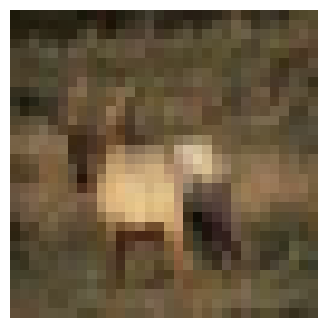

In [8]:
plt.figure(figsize=(4,4))
plt.imshow(X_train[3])
plt.axis('off')
plt.show()

In [9]:
y_train[:50]

array([[6],
       [9],
       [9],
       [4],
       [1],
       [1],
       [2],
       [7],
       [8],
       [3],
       [4],
       [7],
       [7],
       [2],
       [9],
       [9],
       [9],
       [3],
       [2],
       [6],
       [4],
       [3],
       [6],
       [6],
       [2],
       [6],
       [3],
       [5],
       [4],
       [0],
       [0],
       [9],
       [1],
       [3],
       [4],
       [0],
       [3],
       [7],
       [3],
       [3],
       [5],
       [2],
       [2],
       [7],
       [1],
       [1],
       [1],
       [2],
       [2],
       [0]], dtype=uint8)

##### y_train is a 2D array, for our classification having 1D array is good enough. so we will convert this to now 1D array

In [10]:
y_train = y_train.reshape(-1,)
y_train[:5]

array([6, 9, 9, 4, 1], dtype=uint8)

In [11]:
y_test = y_test.reshape(-1,)

In [15]:
classes = ["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]

### Let's plot some images to see what they are

In [12]:
def plot_sample(X, y, index):
    plt.figure(figsize = (15,2))
    plt.imshow(X[index])
    plt.xlabel(classes[y[index]])

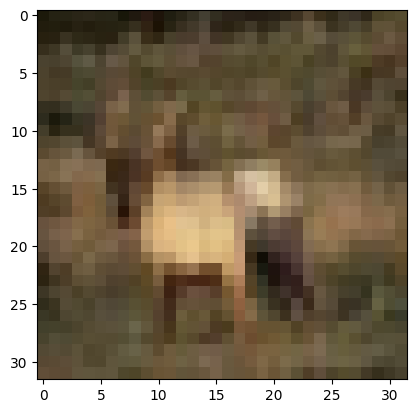

In [13]:
plt.imshow(X_train[3], interpolation='nearest')
plt.show()


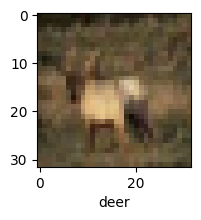

In [16]:
plot_sample(X_train, y_train, 3)

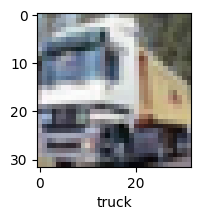

In [17]:
plot_sample(X_train, y_train, 1)

Normalize the images to a number from 0 to 1. Image has 3 channels (R,G,B) and each value in the channel can range from 0 to 255. Hence to normalize in 0-->1 range, we need to divide it by 255

### Normalizing the training data

In [18]:
X_train = X_train / 255.0
X_test = X_test / 255.0

### Build simple artificial neural network for image classification

In [19]:
ann = models.Sequential([
    layers.Flatten(input_shape=(32, 32, 3)),
    layers.Dense(3000, activation='relu'),
    layers.Dense(1000, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann.compile(optimizer='SGD',
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

ann.fit(X_train, y_train, epochs=5)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 127s 81ms/step - accuracy: 0.3013 - loss: 1.9346
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 143s 82ms/step - accuracy: 0.4213 - loss: 1.6445
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 125s 80ms/step - accuracy: 0.4535 - loss: 1.5585
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 131s 84ms/step - accuracy: 0.4761 - loss: 1.4807
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 136s 80ms/step - accuracy: 0.4932 - loss: 1.4350


### You can see that at the end of 5 epochs, accuracy is at around 48.48%

In [20]:
from sklearn.metrics import confusion_matrix , classification_report
import numpy as np
y_pred = ann.predict(X_test)
y_pred_classes = [np.argmax(element) for element in y_pred]

print("Classification Report: \n", classification_report(y_test, y_pred_classes))

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step
Classification Report: 
               precision    recall  f1-score   support

           0       0.59      0.50      0.54      1000
           1       0.48      0.71      0.57      1000
           2       0.48      0.20      0.28      1000
           3       0.44      0.11      0.17      1000
           4       0.61      0.19      0.29      1000
           5       0.33      0.53      0.40      1000
           6       0.50      0.54      0.52      1000
           7       0.44      0.62      0.52      1000
           8       0.62      0.60      0.61      1000
           9       0.41      0.66      0.51      1000

    accuracy                           0.47     10000
   macro avg       0.49      0.47      0.44     10000
weighted avg       0.49      0.47      0.44     10000



### Now let us build a convolutional neural network to train our images

In [21]:
ann.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3000)           │     9,219,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1000)           │     3,001,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │        10,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,230,012 (46.65 MB)

 Trainable params: 12,230,010 (46.65 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [22]:
cnn = models.Sequential([

    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [23]:
cnn.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [23]:
cnn.fit(X_train, y_train, epochs=20)

Epoch 1/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 38s 24ms/step - accuracy: 0.3515 - loss: 1.7597
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 42s 24ms/step - accuracy: 0.5767 - loss: 1.1951
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 37s 24ms/step - accuracy: 0.6368 - loss: 1.0430
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 38s 24ms/step - accuracy: 0.6710 - loss: 0.9347
Epoch 5/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 37s 24ms/step - accuracy: 0.6953 - loss: 0.8773
Epoch 6/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 37s 23ms/step - accuracy: 0.7131 - loss: 0.8289
Epoch 7/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 37s 23ms/step - accuracy: 0.7372 - loss: 0.7691
Epoch 8/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 43s 25ms/step - accuracy: 0.7466 - loss: 0.7313
Epoch 9/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 39s 25ms/step - accuracy: 0.7622 - loss: 0.6879
Epoch 10/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 40s 25ms/step - accuracy: 0.7770 - loss: 0.6521
Epoch 11/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 43s 27ms/step - accuracy: 0.7861 - loss: 0.6180
Epoch 12

### With CNN, at the end 5 epochs, accuracy was at around 70.28% which is a significant improvement over ANN. CNN's are best for image classification and gives superb accuracy. Also computation is much less compared to simple ANN as maxpooling reduces the image dimensions while still preserving the features

In [24]:
cnn.evaluate(X_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.0992 - loss: 2.3205


[2.3208067417144775, 0.09969999641180038]

In [25]:
y_pred = cnn.predict(X_test)
y_pred[:5]

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step


array([[0.09974608, 0.07497595, 0.11819623, 0.10480492, 0.12577888,
        0.08804689, 0.09198087, 0.11162616, 0.1041903 , 0.08065373],
       [0.10008865, 0.07167617, 0.12755552, 0.09889516, 0.12927186,
        0.08368316, 0.09869123, 0.10422828, 0.10526056, 0.08064952],
       [0.10261845, 0.07363044, 0.12149534, 0.09852775, 0.12155649,
        0.08971342, 0.0935073 , 0.11173727, 0.10734631, 0.07986722],
       [0.1052433 , 0.07027292, 0.12660572, 0.09274089, 0.1308824 ,
        0.08645812, 0.09721848, 0.10870503, 0.10706089, 0.0748122 ],
       [0.10264787, 0.08060304, 0.11297119, 0.10038305, 0.12041198,
        0.09229424, 0.09175894, 0.10946877, 0.10622836, 0.08323259]],
      dtype=float32)

In [26]:
y_classes = [np.argmax(element) for element in y_pred]
y_classes[:5]

[np.int64(4), np.int64(4), np.int64(4), np.int64(4), np.int64(4)]

In [27]:
y_test[:5]

array([3, 8, 8, 0, 6], dtype=uint8)

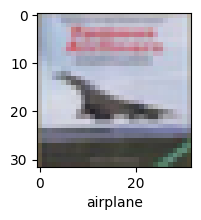

In [28]:
plot_sample(X_test, y_test,3)

In [29]:
classes[y_classes[3]]

'deer'

In [30]:
test_loss, test_accuracy = cnn.evaluate(X_test, y_test, verbose=0)

print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")

Test Loss     : 2.3208
Test Accuracy : 0.0997


In [31]:
import numpy as np

y_pred = cnn.predict(X_test)

# Convert predictions to class labels
y_pred_classes = np.argmax(y_pred, axis=1)

# Convert y_test if one-hot encoded
if len(y_test.shape) > 1:
    y_test_classes = np.argmax(y_test, axis=1)
else:
    y_test_classes = y_test


313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step


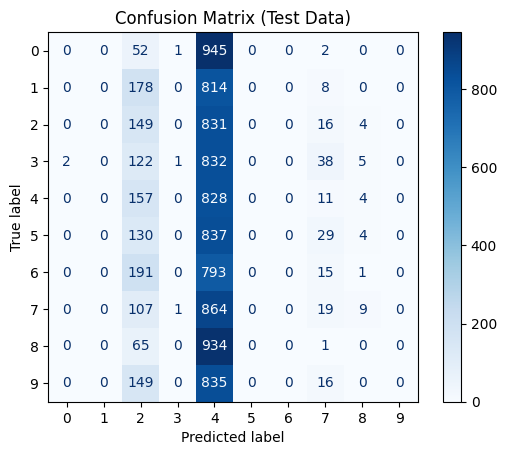

In [32]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test_classes, y_pred_classes)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', values_format='d')

plt.title("Confusion Matrix (Test Data)")
plt.show()


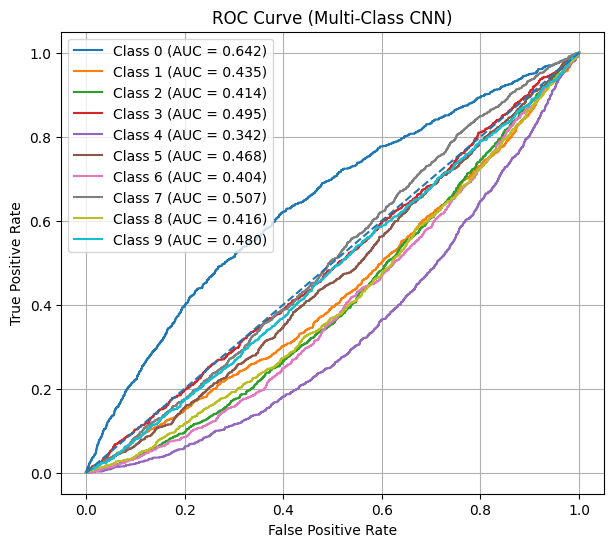

In [33]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

n_classes = y_pred.shape[1]

y_test_bin = label_binarize(
    y_test_classes,
    classes=range(n_classes)
)
plt.figure(figsize=(7, 6))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Multi-Class CNN)")
plt.legend()
plt.grid(True)
plt.show()



In [34]:
cnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,562 (654.54 KB)

 Trainable params: 167,562 (654.54 KB)

 Non-trainable params: 0 (0.00 B)

# CNN MODEL

<img src="images/CNN.jpg" style="width:1200px;height:300px;">

### The formula for calculating a dimension of the output of conv layer is
## ((n+2p-f)/s)+1

In [35]:
!pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 9.7 MB/s eta 0:00:00


In [ ]:
# Hyper parmeters tunning

In [41]:
import keras_tuner as kt
from tensorflow.keras import layers, models
import tensorflow as tf

# Define a model building function for Keras Tuner
def build_model(hp):
    cnn = models.Sequential()

    # First Conv2D Layer
    cnn.add(layers.Conv2D(
        filters=hp.Int('conv_1_filters', min_value=32, max_value=128, step=32),
        kernel_size=(hp.Choice('conv_1_kernel_height', values=[3, 5]),
                     hp.Choice('conv_1_kernel_width', values=[3, 5])),
        activation='relu',
        input_shape=(32, 32, 3))
    )
    cnn.add(layers.MaxPooling2D(pool_size=(2, 2)))

    # Second Conv2D Layer
    cnn.add(layers.Conv2D(
        filters=hp.Int('conv_2_filters', min_value=64, max_value=256, step=64),
        kernel_size=(hp.Choice('conv_2_kernel_height', values=[3, 5]),
                     hp.Choice('conv_2_kernel_width', values=[3, 5])),
        activation='relu')
    )
    cnn.add(layers.MaxPooling2D(pool_size=(2, 2)))

    cnn.add(layers.Flatten())

    # Dense Layer
    cnn.add(layers.Dense(
        units=hp.Int('dense_units', min_value=64, max_value=256, step=64),
        activation='relu')
    )

    # Output Layer
    cnn.add(layers.Dense(10, activation='softmax'))

    # Compile the model
    cnn.compile(
        optimizer=tf.keras.optimizers.Adam(
            hp.Float('learning_rate', min_value=1e-4, max_value=1e-2, sampling='LOG')
        ),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return cnn

# Hyperparameter tuning using Keras Tuner
tuner = kt.Hyperband(
    build_model,
    objective='val_accuracy',
    max_epochs=10,
    factor=3,
    directory='kt_dir',
    project_name='cnn_tuning'
)

# Define a callback for stopping early if no improvements
stop_early = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)

# Start the search for the best hyperparameters
tuner.search(X_train, y_train, epochs=10, validation_data=(X_test, y_test), callbacks=[stop_early])

# Retrieve the best model and hyperparameters
best_model = tuner.get_best_models(num_models=1)[0]
best_hyperparameters = tuner.get_best_hyperparameters(num_trials=1)[0]

# Evaluate the best model
test_loss, test_acc = best_model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc}")
print(f"Best Hyperparameters: {best_hyperparameters.values}")


Reloading Tuner from kt_dir/cnn_tuning/tuner0.json

Search: Running Trial #4

Value             |Best Value So Far |Hyperparameter
128               |96                |conv_1_filters
5                 |5                 |conv_1_kernel_height
3                 |5                 |conv_1_kernel_width
256               |128               |conv_2_filters
3                 |3                 |conv_2_kernel_height
5                 |3                 |conv_2_kernel_width
192               |64                |dense_units
0.0060719         |0.0022035         |learning_rate
2                 |2                 |tuner/epochs
0                 |0                 |tuner/initial_epoch
2                 |2                 |tuner/bracket
0                 |0                 |tuner/round

Epoch 1/2
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 611s 388ms/step - accuracy: 0.1013 - loss: 2.4444 - val_accuracy: 0.1000 - val_loss: 2.3042
Epoch 2/2
 989/1563 ━━━━━━━━━━━━━━━━━━━━ 3:37 378ms/step - accuracy: 0.0972 - loss

KeyboardInterrupt: 

In [40]:
history = best_model.fit(
    X_train, y_train,
    epochs=8,
    validation_data=(X_test, y_test)
)

Epoch 1/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 202s 128ms/step - accuracy: 0.5973 - loss: 1.1347 - val_accuracy: 0.6015 - val_loss: 1.1475
Epoch 2/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 198s 127ms/step - accuracy: 0.6427 - loss: 1.0248 - val_accuracy: 0.6279 - val_loss: 1.0815
Epoch 3/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 213s 134ms/step - accuracy: 0.6674 - loss: 0.9438 - val_accuracy: 0.6298 - val_loss: 1.0689
Epoch 4/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 199s 127ms/step - accuracy: 0.6887 - loss: 0.8808 - val_accuracy: 0.6264 - val_loss: 1.0901
Epoch 5/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 198s 127ms/step - accuracy: 0.7009 - loss: 0.8474 - val_accuracy: 0.6414 - val_loss: 1.0561
Epoch 6/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 199s 127ms/step - accuracy: 0.7193 - loss: 0.7945 - val_accuracy: 0.6360 - val_loss: 1.0684
Epoch 7/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 199s 127ms/step - accuracy: 0.7263 - loss: 0.7693 - val_accuracy: 0.6313 - val_loss: 1.1161
Epoch 8/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 198s 127ms/step - accuracy: 

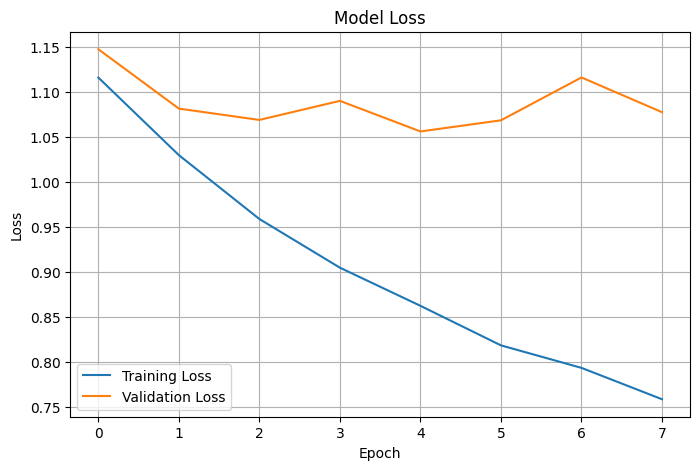

In [45]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Training Loss", "Validation Loss"])
plt.grid(True)
plt.show()

In [43]:
test_loss, test_acc = best_model.evaluate(X_test, y_test)
print("Final Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step - accuracy: 0.6457 - loss: 1.1358
Final Test Accuracy: 0.644599974155426


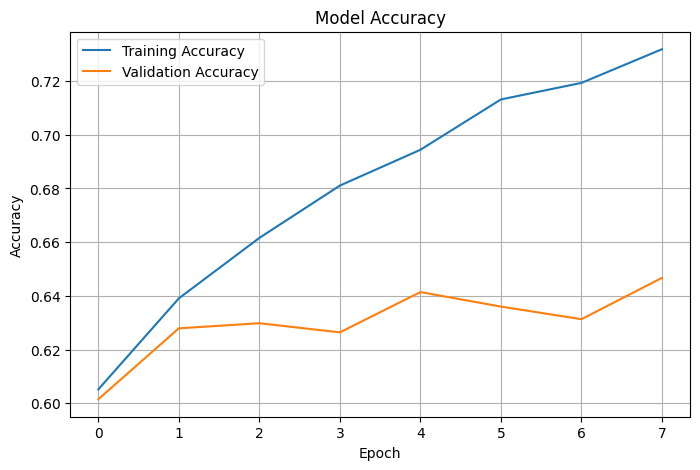

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Training Accuracy", "Validation Accuracy"])
plt.grid(True)
plt.show()

In [38]:
best_model = tuner.get_best_models(num_models=1)[0]

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
